## California Housing Dataset (built into sklearn)

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Analysis (EDA)

## Heatmap

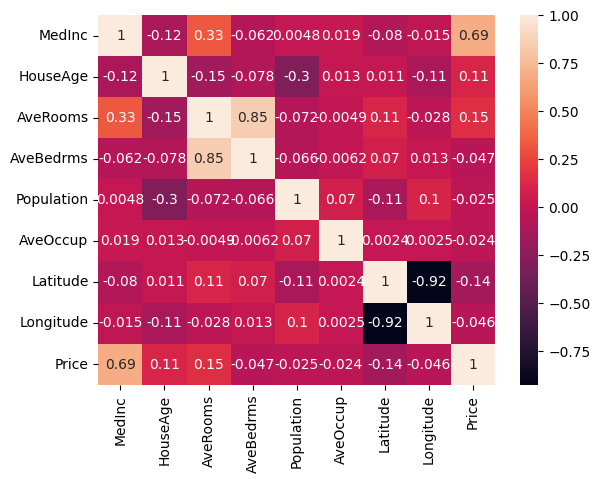

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.show()


## Feature vs Target Relationships

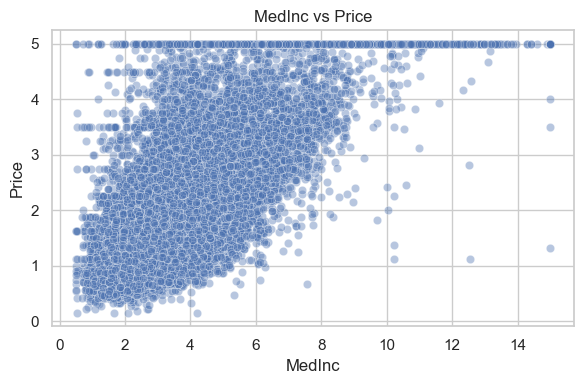

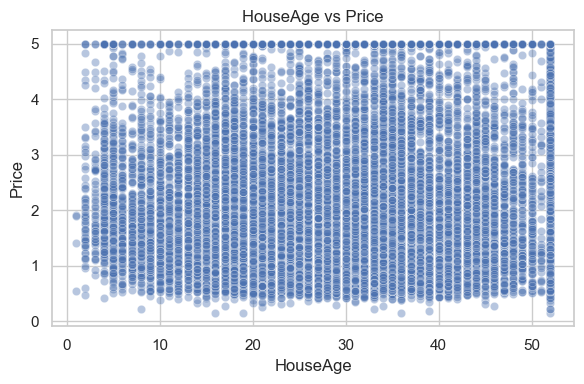

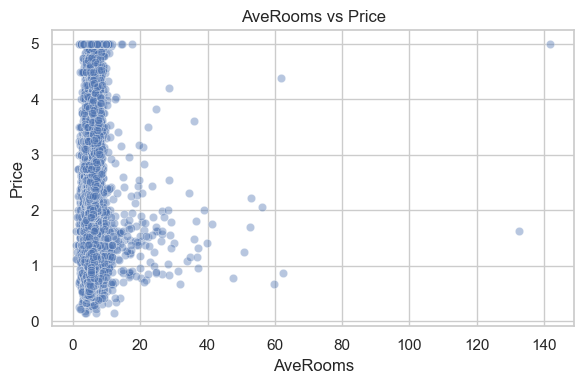

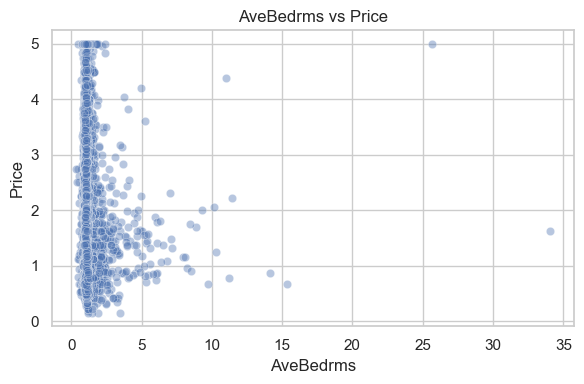

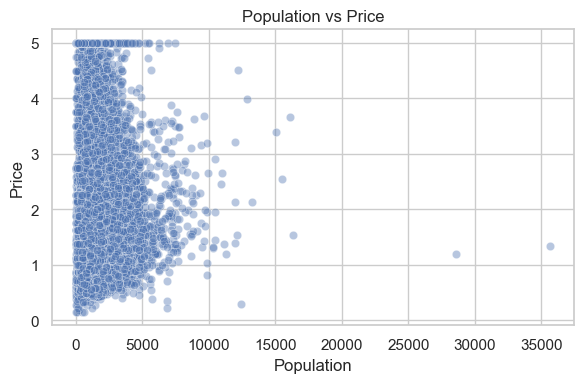

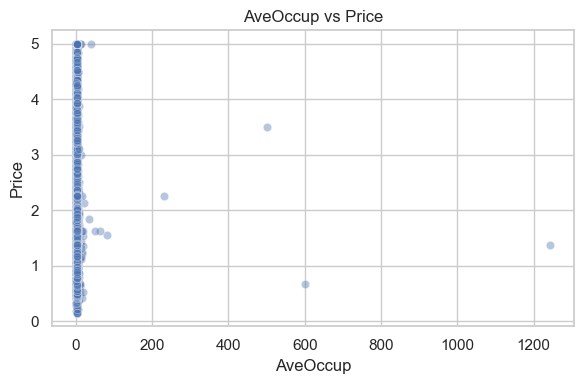

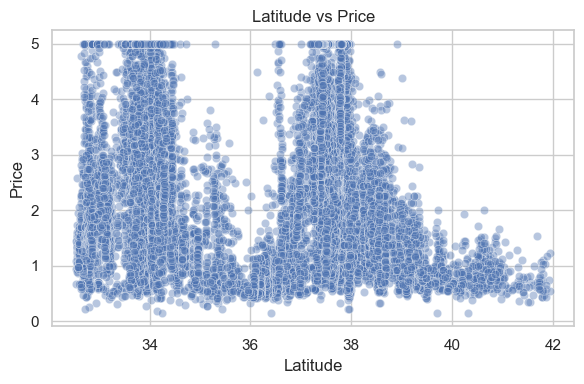

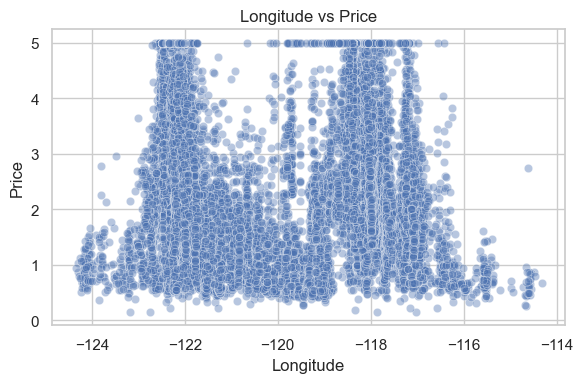

In [ ]:
sns.set(style="whitegrid")
# target column is named 'Price'
target_col = "Price"

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove(target_col)

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target_col], alpha=0.4)
    plt.title(f"{col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

## Outlier Checks (Boxplots)

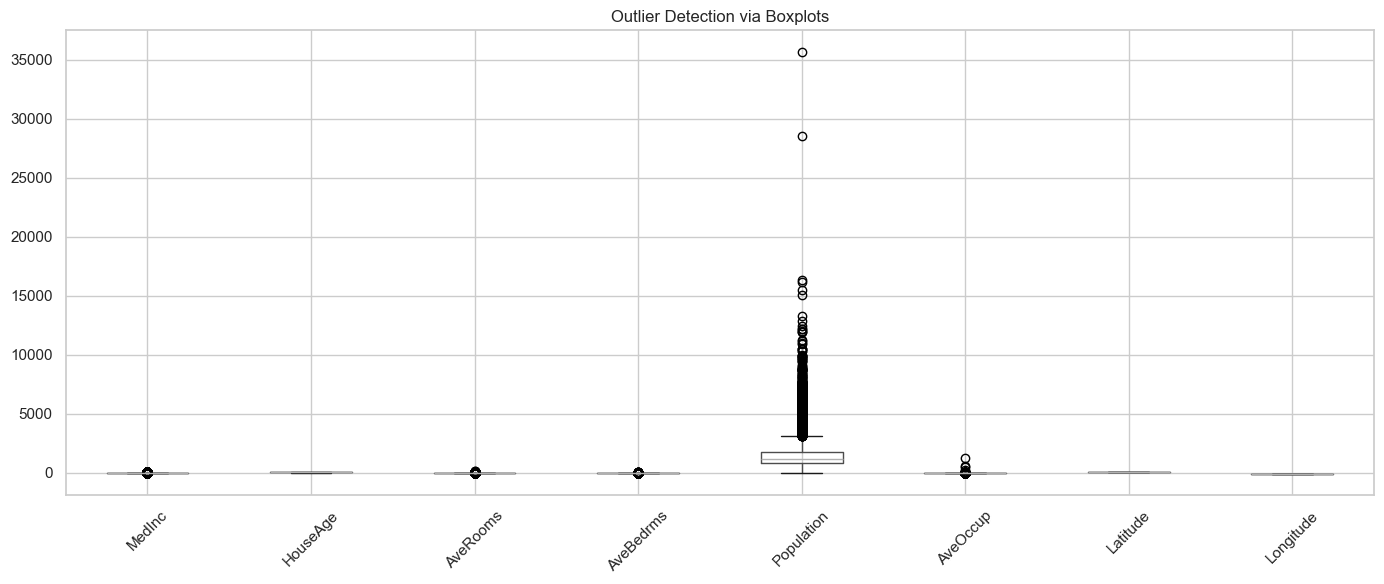

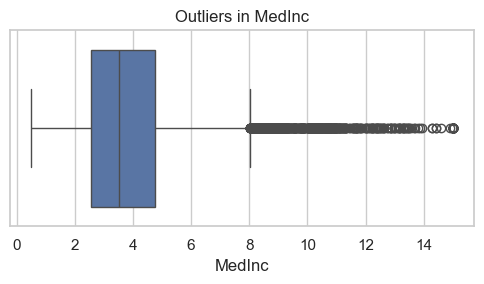

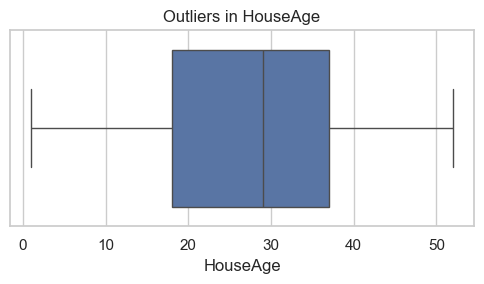

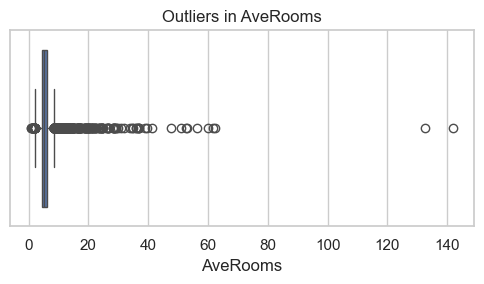

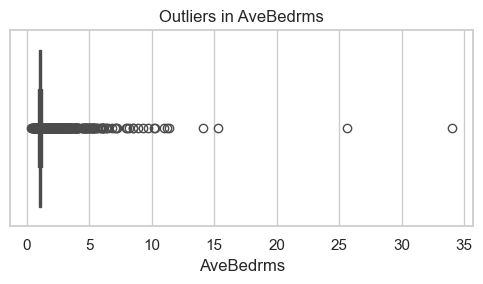

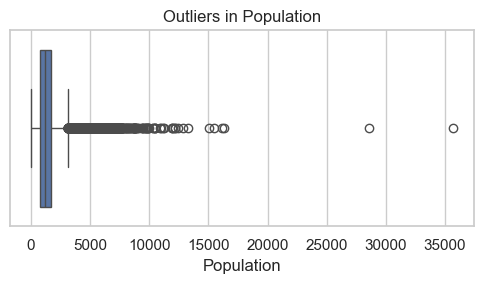

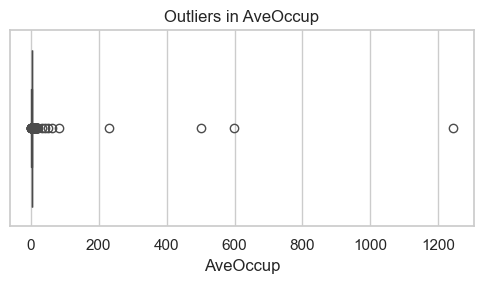

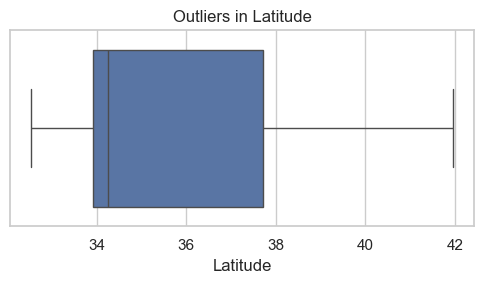

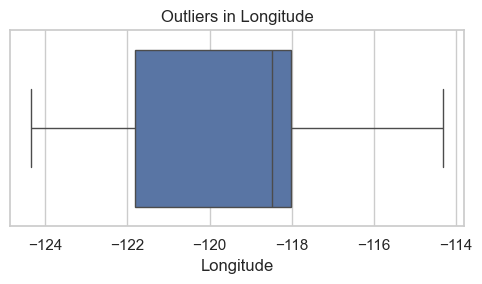

In [21]:
plt.figure(figsize=(14,6))
df[numeric_features].boxplot(rot=45)
plt.title("Outlier Detection via Boxplots")
plt.tight_layout()
plt.show()

# Individual boxplots (clearer view)
for col in numeric_features:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.tight_layout()
    plt.show()

## Feature Distributions

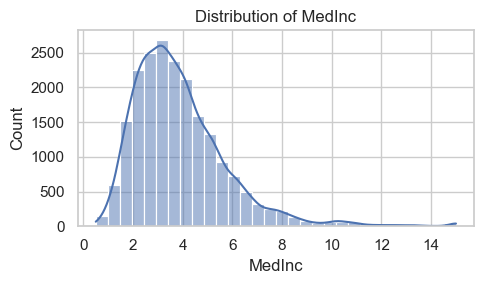

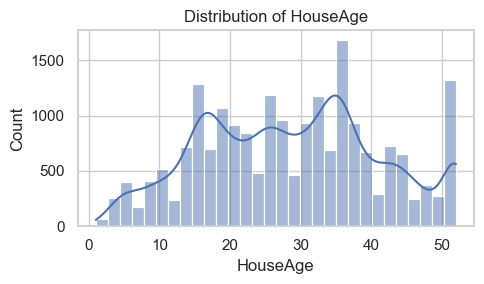

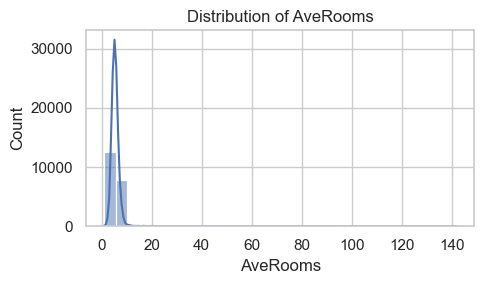

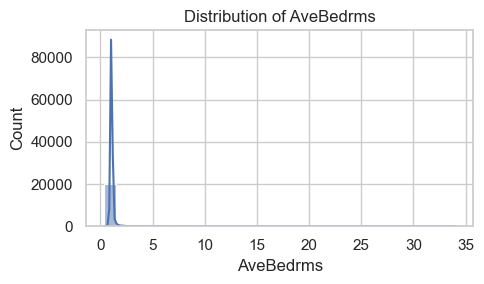

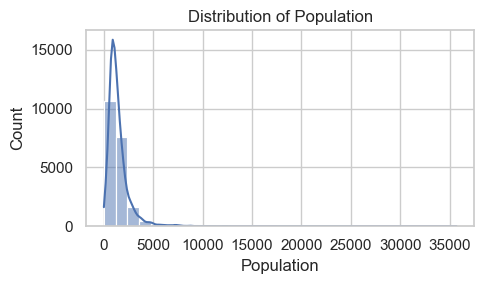

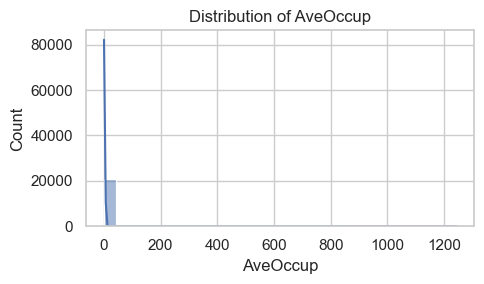

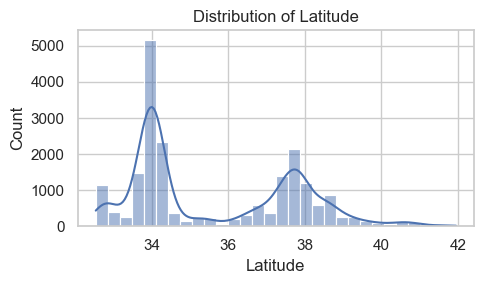

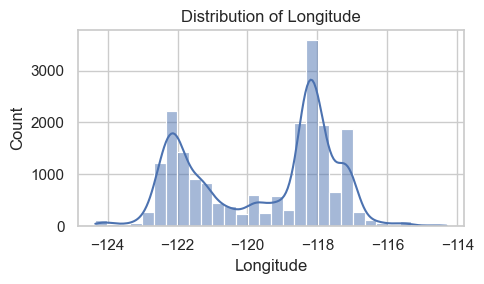

In [22]:
for col in numeric_features:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

## Pairplot (Important Relationships)

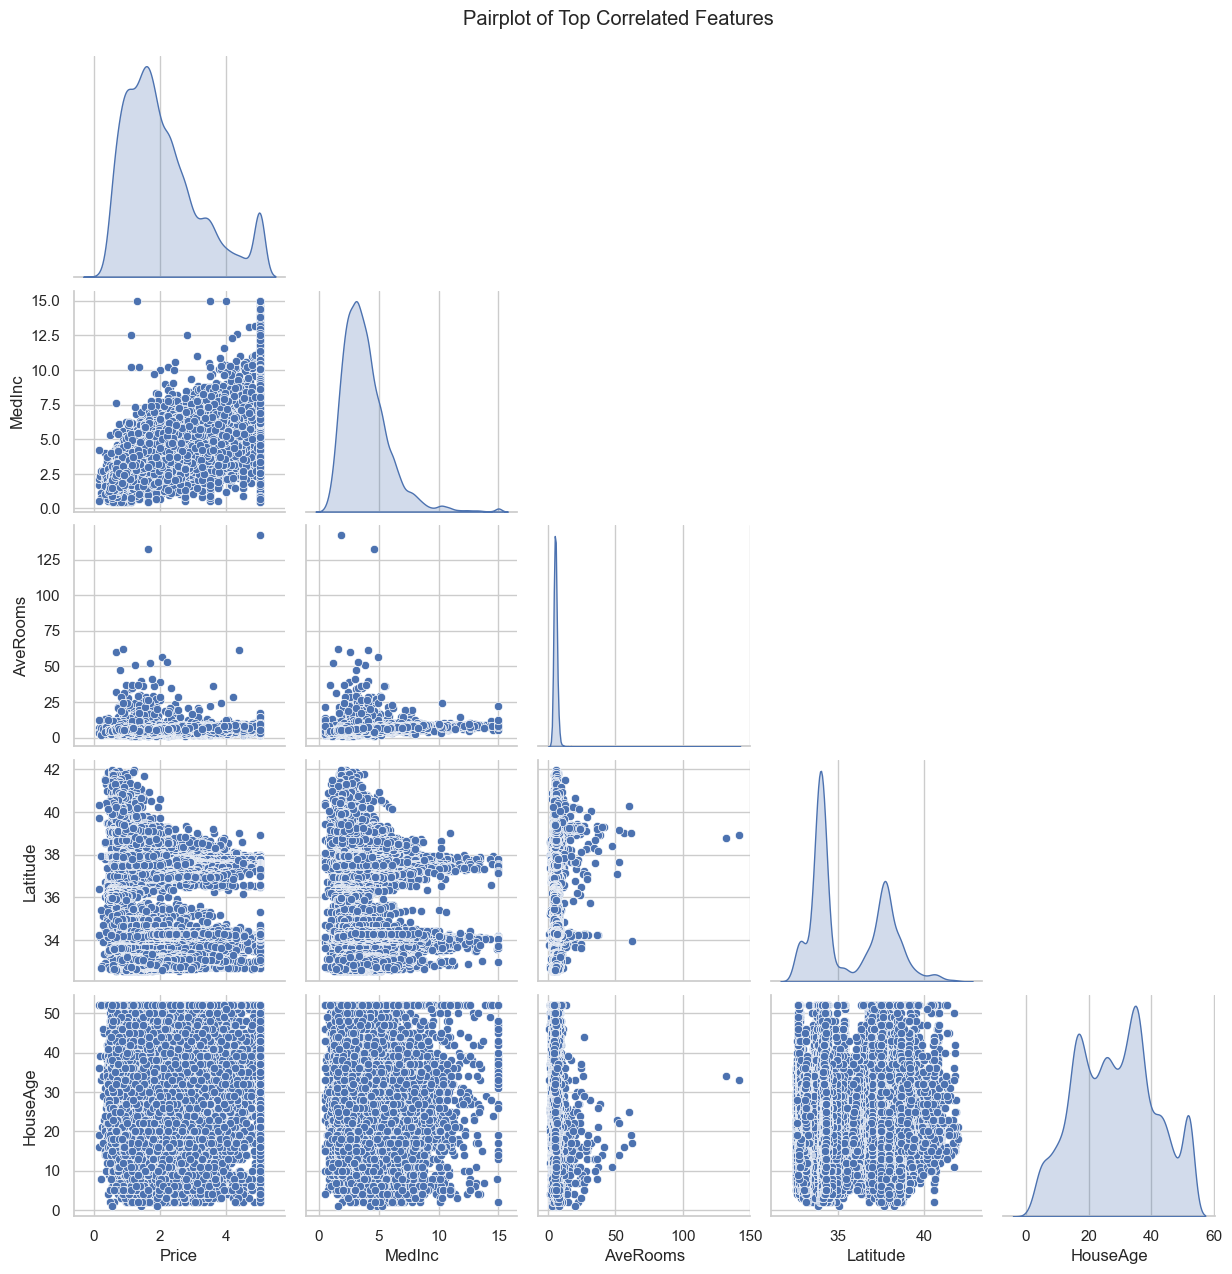

In [24]:
# To avoid very heavy plots, select top correlated features
top_corr_features = (
    df.corr(numeric_only=True)[target_col]
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

sns.pairplot(df[top_corr_features], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Top Correlated Features", y=1.02)
plt.show()

## Optional: Correlation with Target (Cleaner view)

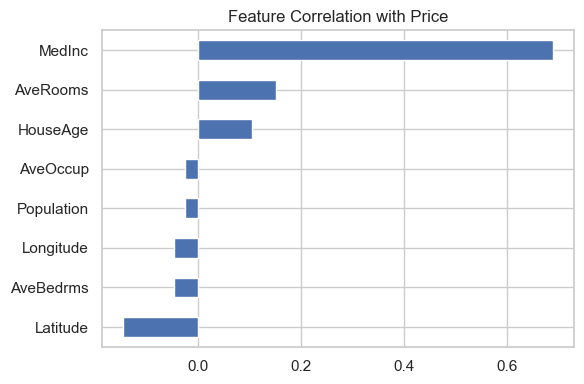

In [25]:
plt.figure(figsize=(6,4))
(
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values()
    .plot(kind="barh")
)
plt.title(f"Feature Correlation with {target_col}")
plt.tight_layout()
plt.show()

## Train Model

### LinearRegression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df.drop('Price', axis=1)
y = df['Price'] ### Separates features and target
                ### Correct for supervised learning

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)               ###  80/20 split
                ### random_state=42 ensures reproducibility
                ### Good practice

model = LinearRegression()
model.fit(X_train, y_train) ### Trains Linear Regression

y_pred = model.predict(X_test)  ### Generates predictions

print("R2:", r2_score(y_test, y_pred)) ### Evaluates model
                                    ### But only one metric (needs improvement)


R2: 0.575787706032451


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
# Centers features around 0
# Scales them to unit variance
# Makes features comparable in size


## Save Model

In [13]:
import joblib
joblib.dump(model, "house_model.pkl")


['house_model.pkl']

## Deploy Web Service (Flask)

In [ ]:
##Flask API works
#POST endpoint
#JSON response
#Loads trained model
###This completes the ML lifecycle — nice work.

In [15]:
%pip install flask
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)
model = joblib.load("house_model.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json["features"]
    prediction = model.predict([data])
    return jsonify({"prediction": float(prediction[0])})

if __name__ == "__main__":
    app.run(debug=True)


  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached werkzeug-3.1.6-py3-none-any.whl.metadata (4.0 kB)
Using cached flask-3.1.3-py3-none-any.whl (103 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl (15 kB)
Using cached werkzeug-3.1.6-py3-none-any.whl (225 kB)
Note: you may need to restart the kernel to use updated packages.
 * Serving Flask app '__main__'
 * Debug mode: on



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

d:\_00.SUNRISE\DS\ML\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
